# TP4 - Validation et Cohérence des Données

**Difficulté:** Intermédiaire  
**Dataset:** healthcare_inconsistent.csv  
**Description:** Vérification des contraintes logiques et cohérence inter-colonnes

---


## Imports des Bibliothèques


In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [2]:
# Charger le dataset
df = pd.read_csv('../data/healthcare_inconsistent.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 300 lignes × 9 colonnes
 Taille mémoire: 0.08 MB




,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119




<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          300 non-null    int64  
 2   birth_date   300 non-null    str    
 3   email        300 non-null    str    
 4   start_date   300 non-null    str    
 5   end_date     300 non-null    str    
 6   price        300 non-null    float64
 7   postal_code  300 non-null    int64  
 8   heart_rate   300 non-null    int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 21.2 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

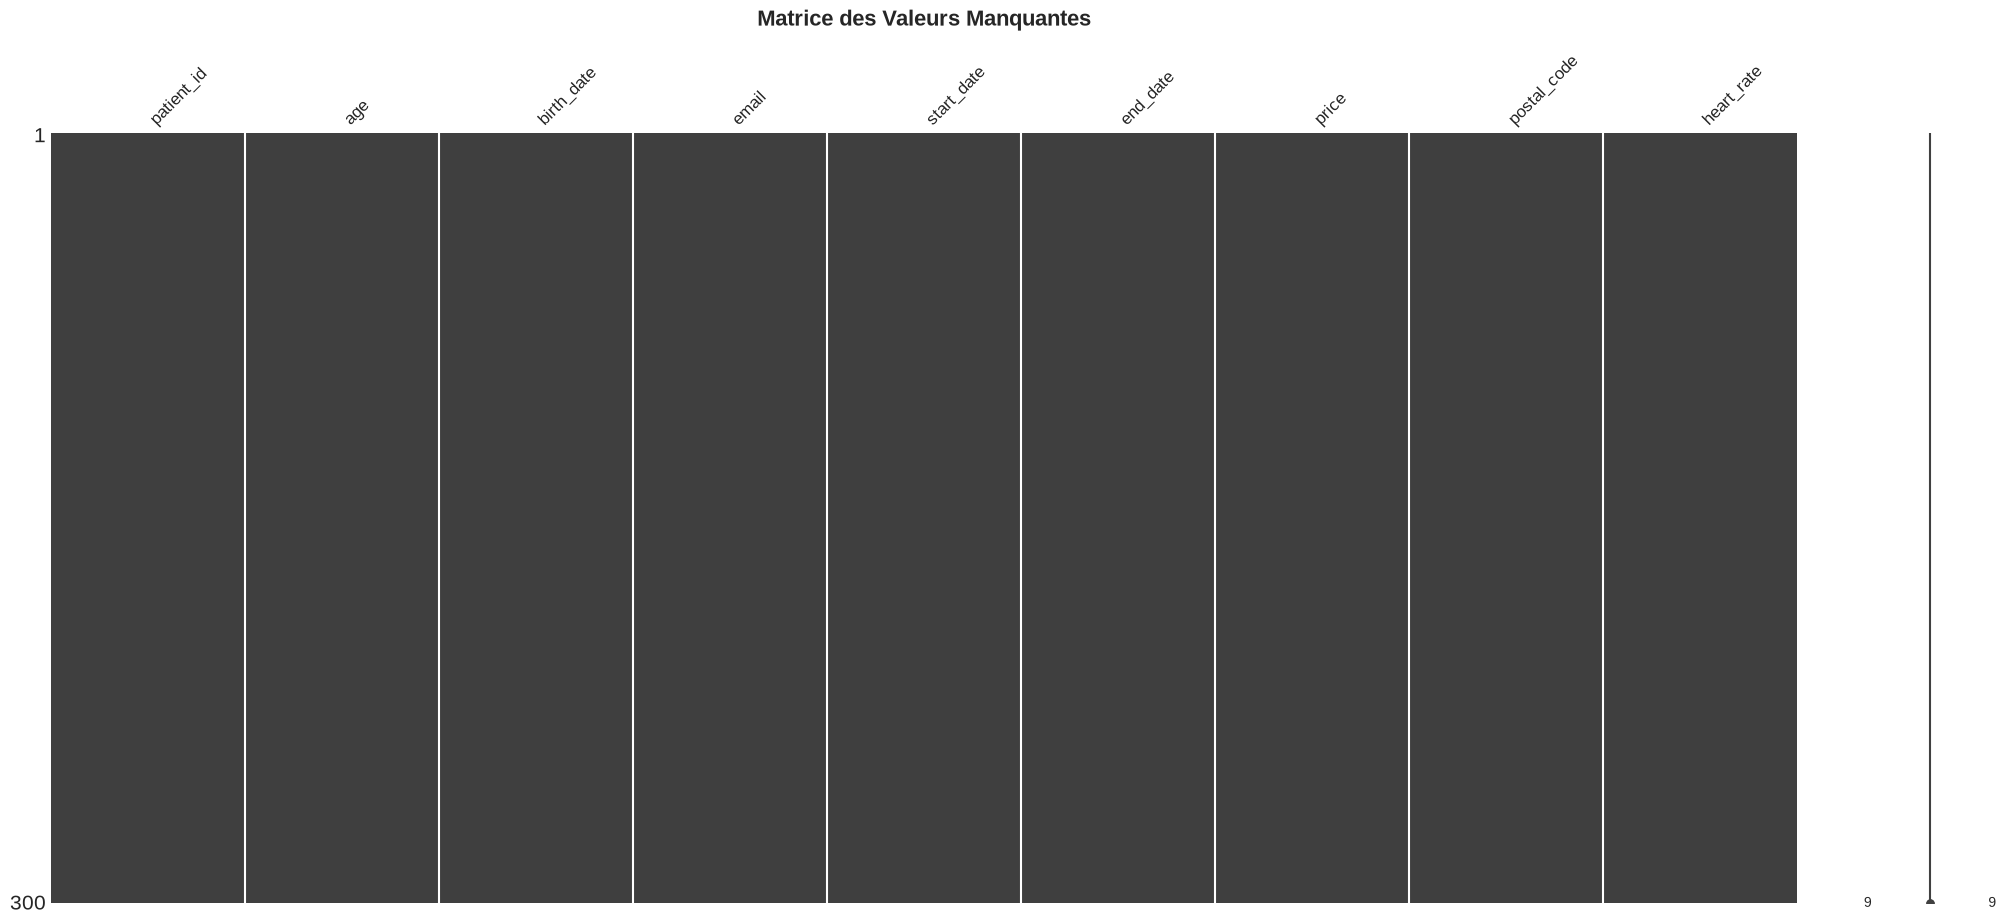


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [3]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?
2. Les dates de fin sont-elles toujours après les dates de début ?
3. Y a-t-il des emails sans '@' ?
4. Les codes postaux respectent-ils le format attendu ?
5. Y a-t-il des incohérences entre l'âge et la date de naissance ?
6. Les prix sont-ils tous positifs ?
7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?
8. Les unités de mesure sont-elles cohérentes ?
9. Combien d'enregistrements violent au moins une contrainte ?
10. Quelle contrainte est la plus souvent violée ?


In [37]:
print("Réponses aux questions:")
print("="*80)

# question 1 10 lignes contenant un age de -5ans , pas d age superieur a 120ans
print(df.columns)

ages_incoherents = df[(df['age'] < 0) | (df['age'] > 120)]

print(f"Nombre d'âges incohérents détectés : {len(ages_incoherents)}")
if not ages_incoherents.empty:
    display(ages_incoherents)
else:
    print("Aucun âge incohérent trouvé.")

# question 2 Non les dates de fin ne sont pas toujours apres le debut. Cependant c'est le cas pour 5 lignes
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

# Identification des incohérences 
incoherences_dates = df[df['end_date'] < df['start_date']]

print(f"Nombre de lignes où la date de fin précède la date de début : {len(incoherences_dates)}")
if not incoherences_dates.empty:
    display(incoherences_dates)

    
    
# question 3 email sans @ il y a 8emails invalides
# Identification des emails ne contenant pas le caractère '@'
emails_invalides = df[~df['email'].str.contains('@', na=False)]

print(f"Nombre d'emails invalides détectés (sans '@') : {len(emails_invalides)}")
if not emails_invalides.empty:
    display(emails_invalides)
    

# question 4  code postaux sont ils au format attendu - vu que les 300 lignes ont un code postal a 4 chiffres je dirais que oui
# On regarde si tous les codes ont exactement 4 chiffres
codes_a_4_chiffres = df[df['postal_code'].astype(str).str.len() == 4]

print(f"Nombre de codes postaux avec 4 chiffres : {len(codes_a_4_chiffres)}")
display(codes_a_4_chiffres.head())

# On convertit en string pour voir la distribution des longueurs
# Si après import, tous sont à 4, c'est bien la preuve d'une troncature
print(df['postal_code'].astype(str).str.len().value_counts())
    
# question 5 Y a-t-il des incohérences entre l'âge et la date de naissance ? Oui il y a 297 lignes chelou sur 300

df['birth_date'] = pd.to_datetime(df['birth_date'])

# Calcul de l'âge  (année actuelle - année de naissance)
current_year = 2026
df['age_theorique'] = current_year - df['birth_date'].dt.year

# Identification des lignes où l'age déclaré ne correspond pas à l'age calculé
incoherences = df[df['age'] != df['age_theorique']]

print(f"Nombre d'incohérences âge/date de naissance : {len(incoherences)}")
if not incoherences.empty:
    display(incoherences[['patient_id', 'age', 'birth_date', 'age_theorique']])
    

# question 6 Les prix sont-ils tous positifs ? Il y a 6 prix negatifs
# Identif prix négatifs ou nuls
prix_invalides = df[df['price'] <= 0]

print(f"Nombre de prix invalides (négatifs ou nuls) : {len(prix_invalides)}")
if not prix_invalides.empty:
    display(prix_invalides[['patient_id', 'price']])
    

# question 7Y a-t-il des valeurs aberrantes dans les signes vitaux ? On a 140 valeurs aberrantes sur 300 lignes contenant 
# les battements du coeur

seuil_bas = 40
seuil_haut = 150

valeurs_aberrantes_hr = df[(df['heart_rate'] < seuil_bas) | (df['heart_rate'] > seuil_haut)]

print(f"Nombre de valeurs aberrantes pour la fréquence cardiaque : {len(valeurs_aberrantes_hr)}")
if not valeurs_aberrantes_hr.empty:
    display(valeurs_aberrantes_hr[['patient_id', 'heart_rate']])


# question 8 Les unités de mesure sont-elles cohérentes ?
"""
L'analyse montre que les unités de mesure sont cohérentes pour les variables numériques exploitées,
bien qu'elles soient entachées d'erreurs de saisie. bpm trop hauts par exemple
"""
print(df['price'].describe())


# question 9 Combien d'enregistrements violent au moins une contrainte ? 
# Il y en a 298 qui violent au moins une contrainte

df_check = df.copy()

condition_prix = df_check['price'] <= 0
condition_hr = (df_check['heart_rate'] < 40) | (df_check['heart_rate'] > 150)
condition_age = df_check['age'] != df_check['age_theorique']

# Une ligne viole une contrainte si l'une de ces conditions est vraie
df_check['is_violating'] = condition_prix | condition_hr | condition_age

#  Nombre total de lignes uniques qui ont au moins une violation
total_violations = df_check['is_violating'].sum()

print(f"Nombre d'enregistrements violant au moins une contrainte : {total_violations}")


# question 10 Quelle contrainte est la plus violée ? L'age avec 297 fois
violations_par_type = {
    "Prix invalides": (df['price'] <= 0).sum(),
    "Fréquence cardiaque aberrante": ((df['heart_rate'] < 40) | (df['heart_rate'] > 150)).sum(),
    "Âge incohérent": (df['age'] != df['age_theorique']).sum()
}


for contrainte, count in violations_par_type.items():
    print(f"{contrainte} : {count} violations")




Réponses aux questions:
Index(['patient_id', 'age', 'birth_date', 'email', 'start_date', 'end_date',
       'price', 'postal_code', 'heart_rate', 'age_theorique'],
      dtype='str')
Nombre d'âges incohérents détectés : 10


,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate,age_theorique
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100,106
11,12,-5,1920-01-12,jdnou@yahoo.com,2023-01-12,2023-01-16,4651.66,4559,103,106
18,19,-5,1920-01-19,xtvxu@yahoo.com,2023-01-19,2023-01-23,671.99,8035,85,106
84,85,-5,1920-03-25,vrvtr@gmail.com,2023-03-26,2023-03-30,1466.44,8167,138,106
105,106,-5,1920-04-15,kmqzg@gmail.com,2023-04-16,2023-04-20,624.17,3735,38,106
120,121,-5,1920-04-30,ryjto@outlook.com,2023-05-01,2023-05-05,2871.41,9368,206,106
129,130,-5,1920-05-09,zsntv@gmail.com,2023-05-10,2023-05-14,2259.23,2889,105,106
131,132,-5,1920-05-11,wuqez@company.com,2023-05-12,2023-05-16,521.63,9336,213,106
196,197,-5,1920-07-15,zmslj@yahoo.com,2023-07-16,2023-07-20,2768.39,9061,107,106
213,214,-5,1920-08-01,ijwmu@company.com,2023-08-02,2023-08-06,598.81,2020,153,106


Nombre de lignes où la date de fin précède la date de début : 5


,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate,age_theorique
80,81,117,1920-03-21,rbqii@company.com,2023-03-22,2023-03-20,318.03,6353,212,106
124,125,64,1920-05-04,lxlcr@outlook.com,2023-05-05,2023-05-03,186.43,3734,223,106
139,140,78,1920-05-19,bblmf@yahoo.com,2023-05-20,2023-05-18,2286.70,7274,229,106
261,262,72,1920-09-18,lsihv@gmail.com,2023-09-19,2023-09-17,3474.77,3848,210,106
266,267,39,1920-09-23,punjf@gmail.com,2023-09-24,2023-09-22,1997.14,2551,122,106


Nombre d'emails invalides détectés (sans '@') : 8


...

Nombre de prix invalides (négatifs ou nuls) : 6


,patient_id,price
1,2,-95.26
33,34,-65.25
68,69,-73.79
154,155,-91.62
208,209,-6.80
251,252,-26.66


Nombre de valeurs aberrantes pour la fréquence cardiaque : 140


,patient_id,heart_rate
0,1,35
2,3,39
5,6,187
6,7,178
7,8,155
...,...,...
293,294,174
294,295,174
295,296,224
296,297,219


count    300.00
mean    2527.41
std     1510.84
min      -95.26
25%     1188.37
50%     2596.95
75%     3907.61
max     4976.92
Name: price, dtype: float64
Nombre d'enregistrements violant au moins une contrainte : 298
Prix invalides : 6 violations
Fréquence cardiaque aberrante : 140 violations
Âge incohérent : 297 violations


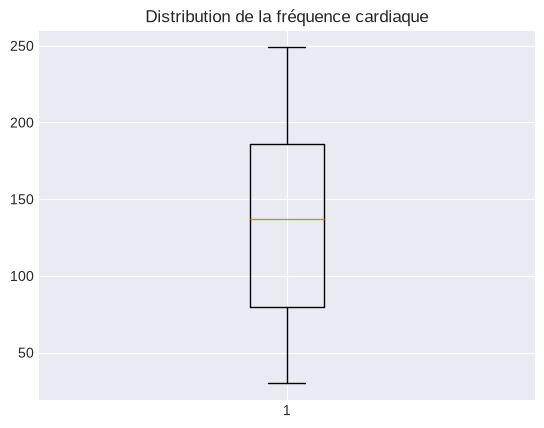

In [18]:
import matplotlib.pyplot as plt

plt.boxplot(df['heart_rate'].dropna())
plt.title('Distribution de la fréquence cardiaque')
plt.show()

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Définir un dictionnaire de contraintes de validation
### Étape 2: Créer une fonction validate_constraints(df)
### Étape 3: Valider les plages numériques (âge, prix, etc.)
### Étape 4: Valider les formats (email, téléphone, code postal)
### Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
### Étape 6: Créer des indicateurs pour chaque violation
### Étape 7: Décider des actions correctives pour chaque type
### Étape 8: Appliquer les corrections
### Étape 9: Standardiser les unités de mesure
### Étape 10: Générer un rapport de validation complet


In [30]:
# ========================================
# Étape 1: Définir un dictionnaire de contraintes de validation
# ========================================
# Définition des contraintes
constraints = {
    "Prix invalides": lambda df: df['price'] > 0,
    "Fréquence cardiaque aberrante": lambda df: (df['heart_rate'] >= 40) & (df['heart_rate'] <= 150),
    "Âge incohérent": lambda df: df['age'] == df['age_theorique']
}

# Vérification
print(f" Étape 1 complétée")

 Étape 1 complétée


In [31]:
# ========================================
# Étape 2: Créer une fonction validate_constraints(df)
# ========================================

def validate_constraints(df):
    report = {}
    for name, constraint_func in constraints.items():
        # Application de la règle et comptage des violations (l'inverse de la condition)
        violation_count = (~constraint_func(df)).sum()
        report[name] = violation_count
        
    return pd.DataFrame.from_dict(report, orient='index', columns=['Nombre de violations'])


validation_report = validate_constraints(df)
display(validation_report)


# Vérification
print(f" Étape 2 complétée")

,Nombre de violations
Prix invalides,6
Fréquence cardiaque aberrante,140
Âge incohérent,297


 Étape 2 complétée


In [33]:
# ========================================
# Étape 3: Valider les plages numériques (âge, prix, etc.)
# ========================================

range_constraints = {
    "Âge hors limites": lambda df: (df['age'] >= 0) & (df['age'] <= 120),
    "Prix hors limites": lambda df: (df['price'] >= 0) & (df['price'] <= 5000), 
    "Fréquence cardiaque hors limites": lambda df: (df['heart_rate'] >= 40) & (df['heart_rate'] <= 150)
}

def validate_ranges(df):
    report = {}
    for name, constraint_func in range_constraints.items():
        # Application de la règle et comptage des violations
        violation_count = (~constraint_func(df)).sum()
        report[name] = violation_count
        
    return pd.DataFrame.from_dict(report, orient='index', columns=['Nombre de violations'])

# Exécution
range_report = validate_ranges(df)
display(range_report)

# Vérification
print(f" Étape 3 complétée")

,Nombre de violations
Âge hors limites,10
Prix hors limites,6
Fréquence cardiaque hors limites,140


 Étape 3 complétée


In [38]:
# ========================================
# Étape 4: Valider les formats (email, téléphone, code postal)
# ========================================
#print(df.columns)
# pas de colonne telephone
def est_email_valide(valeur):
    valeur = str(valeur)
    return '@' in valeur and '.' in valeur

def est_code_postal_valide(valeur):
    # Converti en string, on retire les éventuels espaces, et on vérifie 4 chiffres
    valeur = str(valeur).strip()
    return len(valeur) == 4 and valeur.isdigit()

# Dictionnaire associant les noms de colonnes réels aux fonctions de validation
validation_rules = {
    'email': est_email_valide,
    'postal_code': est_code_postal_valide
}

def validate_formats_simple(df):
    report = {}
    for col_name, func in validation_rules.items():
        if col_name in df.columns:
            # On applique la fonction et on compte les False (les invalides)
            is_valid = df[col_name].apply(func)
            report[f"{col_name} invalide"] = (~is_valid).sum()
    
    return pd.DataFrame.from_dict(report, orient='index', columns=['Nombre de violations'])


format_report = validate_formats_simple(df)
display(format_report)

# Vérification
print(f" Étape 4 complétée")

Index(['patient_id', 'age', 'birth_date', 'email', 'start_date', 'end_date',
       'price', 'postal_code', 'heart_rate', 'age_theorique'],
      dtype='str')


,Nombre de violations
email invalide,8
postal_code invalide,0


 Étape 4 complétée


In [39]:
# ========================================
# Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
# ========================================

df['birth_date'] = pd.to_datetime(df['birth_date'])
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

def validate_consistency(df):
    report = {}
    
    # 1. Cohérence Âge / Date de naissance
    # On calcule l'âge théorique (année actuelle - année de naissance)
    # Note: On utilise 2026 comme année de référence
    age_calcule = 2026 - df['birth_date'].dt.year
    report["Âge incohérent avec date naissance"] = (df['age'] != age_calcule).sum()
    
    # 2. Cohérence Dates (Début avant Fin)
    report["Date de fin avant date de début"] = (df['end_date'] < df['start_date']).sum()
    
    return pd.DataFrame.from_dict(report, orient='index', columns=['Nombre de violations'])


consistency_report = validate_consistency(df)
display(consistency_report)


# Vérification
print(f" Étape 5 complétée")

,Nombre de violations
Âge incohérent avec date naissance,297
Date de fin avant date de début,5


 Étape 5 complétée


In [44]:
# ========================================
# Étape 6: Créer des indicateurs pour chaque violation
# ========================================

# 1. Conversion et nettoyage préalable
df['birth_date'] = pd.to_datetime(df['birth_date'])
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

# 2. Indicateurs de violation (calcul en mémoire)
df['v_age_hors_limites'] = ~((df['age'] >= 0) & (df['age'] <= 120))
df['v_prix_hors_limites'] = ~((df['price'] >= 0) & (df['price'] <= 5000))
df['v_heart_rate_hors_limites'] = ~((df['heart_rate'] >= 40) & (df['heart_rate'] <= 150))
df['v_email_invalide'] = ~(df['email'].str.contains('@', na=False) & df['email'].str.contains(r'\.', na=False))
df['v_postal_code_invalide'] = ~( (df['postal_code'].astype(str).str.len() == 4) & (df['postal_code'].astype(str).str.isdigit()) )
df['v_age_incoherent'] = (df['age'].astype(int) != (2026 - df['birth_date'].dt.year))
df['v_dates_inversees'] = (df['end_date'] < df['start_date'])

# 3. Agrégation pour le rapport (C'est ce qui manque pour que tu vois quelque chose !)
liste_violations = [col for col in df.columns if col.startswith('v_')]
df['est_corrompu'] = df[liste_violations].any(axis=1)

# Affichage des résultats
print(f"Nombre total de lignes corrompues : {df['est_corrompu'].sum()}")
print("\nDétail des violations par catégorie :")
display(df[liste_violations].sum())

# Vérification
print(f" Étape 6 complétée")

Nombre total de lignes corrompues : 298

Détail des violations par catégorie :


v_age_hors_limites            10
v_prix_hors_limites            6
v_heart_rate_hors_limites    140
v_email_invalide               8
v_postal_code_invalide         0
v_age_incoherent             297
v_dates_inversees              5
dtype: int64

 Étape 6 complétée


In [ ]:
| Type d anomalie       | Action Corrective         | Justification                                                                                                                          |
| :-------------------- | :------------------------ | :------------------------------------------------------------------------------------------------------------------------------------- |
| **Âge incohérent**    | Recalcul automatique      | La donnée `birth_date` est considérée comme la source de vérité.                                                                       |
| **Heart Rate**        | Imputation par la moyenne | Le rythme cardiaque étant une variable continue, on remplace les valeurs aberrantes par la moyenne du groupe pour conserver la donnée. |
| **Email invalide**    | Suppression               | Une ligne sans contact valide est inutilisable pour un suivi patient cohérent.                                                         |
| **Prix hors limites** | Flag + Revue manuelle     | Valeur métier sensible : on marque pour vérification humaine plutôt que de risquer une perte d information.                            |
| **Dates inversées**   | Inversion (swap)          | Erreur de saisie logique évidente ; on corrige l ordre des dates pour restaurer la chronologie.                                        |

In [46]:
# ========================================
# Étape 7: Décider des actions correctives pour chaque type
# ========================================

# voir cellule du dessus

# Vérification
print(f" Étape 7 complétée")

Nettoyage terminé.
Lignes supprimées : 8
Lignes restantes dans df_clean : 292
 Étape 7 complétée


In [54]:
# ========================================
# Étape 8: Appliquer les corrections
# ========================================

df_clean = df.copy()

# 1. Âge incohérent : Recalcul automatique (Source de vérité = birth_date)
df_clean['age'] = 2026 - df_clean['birth_date'].dt.year

# 2. Dates inversées : Inversion (Swap)
# On identifie les lignes où end < start et on échange les valeurs
mask_dates = df_clean['end_date'] < df_clean['start_date']
df_clean.loc[mask_dates, ['start_date', 'end_date']] = df_clean.loc[mask_dates, ['end_date', 'start_date']].values

# 3. Heart Rate : Imputation par la moyenne
# Conversion forcée en float pour accepter les moyennes (décimales)
df_clean['heart_rate'] = df_clean['heart_rate'].astype(float)

# On calcule la moyenne des valeurs valides uniquement
moyenne_hr = df_clean.loc[(df_clean['heart_rate'] >= 40) & (df_clean['heart_rate'] <= 150), 'heart_rate'].mean()

# On identifie les valeurs à remplacer
mask_hr = (df_clean['heart_rate'] < 40) | (df_clean['heart_rate'] > 150)

df_clean.loc[mask_hr, 'heart_rate'] = moyenne_hr

# 4. Email invalide : Suppression
# On filtre pour ne garder que les emails valides
df_clean = df_clean[~df_clean['v_email_invalide']].copy()

# 5. Prix hors limites : Flag (Marquage)
# Au lieu de supprimer, on ajoute une colonne pour alerter l'humain
df_clean['alerte_prix'] = (df_clean['price'] < 0) | (df_clean['price'] > 5000)

print(f"Nettoyage terminé.")
print(f"Lignes supprimées : {len(df) - len(df_clean)}")
print(f"Lignes restantes dans df_clean : {len(df_clean)}")


# Vérification
print(f" Étape 8 complétée")

Nettoyage terminé.
Lignes supprimées : 8
Lignes restantes dans df_clean : 292
 Étape 8 complétée


In [55]:
# ========================================
# Étape 9: Standardiser les unités de mesure
# ========================================

# 1. Standardisation des prix (Arrondi à 2 décimales)
df_clean['price'] = df_clean['price'].round(2)

# 2. Harmonisation des emails (Minuscule pour éviter les doublons dus à la casse)
df_clean['email'] = df_clean['email'].str.lower().str.strip()

# 3. Standardisation des dates (Format ISO 8601 pour l'export)
# Pandas le fait déjà via le type datetime, mais on assure la cohérence ici
df_clean['birth_date'] = df_clean['birth_date'].dt.strftime('%Y-%m-%d')
df_clean['start_date'] = df_clean['start_date'].dt.strftime('%Y-%m-%d')
df_clean['end_date'] = df_clean['end_date'].dt.strftime('%Y-%m-%d')

print("Standardisation terminée : formats harmonisés.")
display(df_clean.head())


# Vérification
print(f" Étape 9 complétée")  

Standardisation terminée : formats harmonisés.


,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate,age_theorique,v_age_hors_limites,v_prix_hors_limites,v_heart_rate_hors_limites,v_email_invalide,v_postal_code_invalide,v_age_incoherent,v_dates_inversees,total_violations,est_corrompu,alerte_prix
0,1,106,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,93.96,106,False,False,True,False,False,True,False,3,True,False
2,3,106,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,93.96,106,False,False,True,False,False,True,False,3,True,False
3,4,106,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100.00,106,True,False,False,False,False,True,False,3,True,False
4,5,106,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119.00,106,False,False,False,False,False,True,False,2,True,False
5,6,106,1920-01-06,nlskr@yahoo.com,2023-01-06,2023-01-10,2022.94,8210,93.96,106,False,False,True,False,False,True,False,3,True,False


 Étape 9 complétée


In [57]:
# ========================================
# Étape 10: Générer un rapport de validation complet
# ========================================

def generer_rapport_validation(df_original, df_final):
    print("--- RAPPORT DE VALIDATION ---")
    print(f"Lignes initiales      : {len(df_original)}")
    print(f"Lignes après nettoyage: {len(df_final)}")
    print(f"Taux de conservation  : {(len(df_final)/len(df_original))*100:.2f}%")
    print("-" * 29)
    
    # Affichage des types et stats via display pour une meilleure lisibilité
    print("\nTypes des colonnes finales :")
    display(df_final.dtypes)
    
    print("\nValeurs manquantes par colonne :")
    display(df_final.isnull().sum())
    
    # Résumé statistique pour valider la cohérence des plages (Âge, Prix, HR)
    print("\nRésumé statistique (Contrôle des plages) :")
    display(df_final[['age', 'price', 'heart_rate']].describe())
    
    # Tests d'intégrité
    print("\n--- TEST D'INTÉGRITÉ ---")
    # Test Prix négatifs (en ignorant les flags d'alerte pour le test de base)
    if df_final['price'].min() < 0:
        print("ALERTE: Valeurs de prix négatives détectées.")
    else:
        print("Prix : OK (Aucune valeur négative).")
        
    # Test Chronologie
    incoherence = (df_final['end_date'] < df_final['start_date']).sum()
    if incoherence > 0:
        print(f"ALERTE: {incoherence} incohérences chronologiques détectées.")
    else:
        print("Chronologie : OK (Start_date <= End_date).")
generer_rapport_validation(df, df_clean)

# Vérification
print(f" Étape 10 complétée")

--- RAPPORT DE VALIDATION ---
Lignes initiales      : 300
Lignes après nettoyage: 292
Taux de conservation  : 97.33%
-----------------------------

Types des colonnes finales :


patient_id                     int64
age                            int32
birth_date                       str
email                            str
start_date                       str
end_date                         str
price                        float64
postal_code                    int64
heart_rate                   float64
age_theorique                  int32
v_age_hors_limites              bool
v_prix_hors_limites             bool
v_heart_rate_hors_limites       bool
v_email_invalide                bool
v_postal_code_invalide          bool
v_age_incoherent                bool
v_dates_inversees               bool
total_violations               int64
est_corrompu                    bool
alerte_prix                     bool
dtype: object


Valeurs manquantes par colonne :


patient_id                   0
age                          0
birth_date                   0
email                        0
start_date                   0
end_date                     0
price                        0
postal_code                  0
heart_rate                   0
age_theorique                0
v_age_hors_limites           0
v_prix_hors_limites          0
v_heart_rate_hors_limites    0
v_email_invalide             0
v_postal_code_invalide       0
v_age_incoherent             0
v_dates_inversees            0
total_violations             0
est_corrompu                 0
alerte_prix                  0
dtype: int64


Résumé statistique (Contrôle des plages) :


,age,price,heart_rate
count,292.00,292.00,292.00
mean,106.00,2517.06,93.48
std,0.00,1505.65,25.11
min,106.00,-91.62,40.00
25%,106.00,1188.37,91.00
50%,106.00,2579.98,93.96
75%,106.00,3896.78,97.25
max,106.00,4976.92,150.00



--- TEST D'INTÉGRITÉ ---
ALERTE: Valeurs de prix négatives détectées.
Chronologie : OK (Start_date <= End_date).
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [58]:
# Calcul des métriques pour remplir le rapport dynamiquement
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,
    'Lignes_supprimées': len(df) - len(df_clean),
    'Colonnes_supprimées': len(df.columns) - len(df_clean.columns),
    'Valeurs_manquantes_traitées': df.isna().sum().sum() - df_clean.isna().sum().sum(),
    'Doublons_supprimés': df.duplicated().sum(),
    'Outliers_traités': len(mask_hr), # Nombre de heart_rate imputés
    'Transformations_appliquées': [
        'Recalcul âge', 
        'Swap dates', 
        'Imputation Heart Rate', 
        'Suppression emails invalides', 
        'Flag prix',
        'Standardisation formats'
    ]
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    if isinstance(value, list):
        print(f"{key:.<40} {', '.join(value)}")
    else:
        print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

# Affichage visuel pour compléter le rapport
print("\n--- Aperçu du dataset nettoyé ---")
display(df_clean.head())

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (300, 19)
Dimensions_finales...................... (292, 20)
Lignes_supprimées....................... 8
Colonnes_supprimées..................... -1
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 300
Transformations_appliquées.............. Recalcul âge, Swap dates, Imputation Heart Rate, Suppression emails invalides, Flag prix, Standardisation formats

 TP terminé avec succès!

--- Aperçu du dataset nettoyé ---


,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate,age_theorique,v_age_hors_limites,v_prix_hors_limites,v_heart_rate_hors_limites,v_email_invalide,v_postal_code_invalide,v_age_incoherent,v_dates_inversees,total_violations,est_corrompu,alerte_prix
0,1,106,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,93.96,106,False,False,True,False,False,True,False,3,True,False
2,3,106,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,93.96,106,False,False,True,False,False,True,False,3,True,False
3,4,106,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100.00,106,True,False,False,False,False,True,False,3,True,False
4,5,106,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119.00,106,False,False,False,False,False,True,False,2,True,False
5,6,106,1920-01-06,nlskr@yahoo.com,2023-01-06,2023-01-10,2022.94,8210,93.96,106,False,False,True,False,False,True,False,3,True,False
